<a href="https://colab.research.google.com/github/belgiyakilinc/Buy-Now-Pay-Later-Credit-Risk-Prediction/blob/main/BNPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DATA DESCRIPTION

Buy Now, Pay Later (BNPL) is one of the fastest-growing fintech segments globally. This synthetic dataset simulates 10,345 BNPL transactions across 6 countries (2023–2024), designed for building credit risk and default prediction models.



## 1. Data Content

- user_id	<--> Unique user identifier
- age	<--> User age (18–59)
- employment_type	<--> 	Salaried / Self-Employed / Student / Unemployed
- monthly_income <--> 	Monthly income in USD
- credit_score <--> Standard credit score (300–850)
- purchase_amount	<--> 	BNPL transaction value in USD
- product_category	<--> 	Electronics, Fashion, Sports, Home, Beauty
- bnpl_installments	<--> Number of repayment installments (3, 6, 9, 12)
- repayment_delay_days	<-->	Days delayed beyond due date (0–33)
- missed_payments	<-->	Total missed payments (0–7)
- default_flag	<--> Target: 1 = Defaulted, 0 = Paid ✅
- app_usage_frequency	<-->	App opens per week
- location	<--> Country (USA, India, UK, Germany, Canada, Australia)
- transaction_date	<-->	Date of purchase (YYYY-MM-DD)
- debt_to_income_ratio	<-->	DTI ratio (monthly debt / monthly income)
- risk_score	<-->	Composite risk score (0–398) — higher = more risky
- customer_segment	<-->	Low Risk / Medium Risk / High Risk

## Analysis Content
1. Data Content
2. Python Libraries
3. Read and Analyse Data
4. Histogram and box plots for numerical variables
5. Bivariate Variable Analysis
6. Correlation Between Features with Phik
7. Correlation Between Target with Phik
8. Label Encoding
9. Modelling: XGBoost + Lightgbm + Logistic Regression
10. Result

## 2. Python Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.ticker as ticker
# !pip install Phik
import phik

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shree0910/buy-now-and-pay-later-fintech-ml-dataset")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Using Colab cache for faster access to the 'buy-now-and-pay-later-fintech-ml-dataset' dataset.
/kaggle/input/buy-now-and-pay-later-fintech-ml-dataset/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv


## 3. Read and Analyse Data

In [5]:
data= pd.read_csv("/kaggle/input/buy-now-and-pay-later-fintech-ml-dataset/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv")
data.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

In [7]:
data.describe()

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000


In [8]:
# objects datas
object_columns = data.select_dtypes(include=['object']).columns

# cardinality table
cardinality_data = pd.DataFrame({
    'column ': data.select_dtypes(include=['object']).columns,
    'Cardinality': data.select_dtypes(include=['object']).nunique().values,
    'Unique values ': [data[col].unique().tolist() for col in object_columns]
})
print(cardinality_data)

            column   Cardinality  \
0   employment_type            4   
1  product_category            5   
2          location            6   
3  transaction_date          365   
4  customer_segment            3   

                                      Unique values   
0     [Salaried, Student, Self-Employed, Unemployed]  
1       [Electronics, Fashion, Sports, Home, Beauty]  
2       [Australia, USA, Germany, India, Canada, UK]  
3  [2023-06-10, 2024-10-07, 2023-04-05, 2023-06-2...  
4                 [Medium Risk, High Risk, Low Risk]  


In [9]:
# Converting date data from Object to DateTime

data['transaction_date'] = pd.to_datetime(
    data['transaction_date'],
    format='%Y-%m-%d'
)
data["transaction_date"].dtype

dtype('<M8[ns]')

In [ ]:
# !pip install ydata-profiling
# ydata-profolling library is a library for exploratory data analysis reports

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

ydata_report = ProfileReport(data, title="ydata_report - Buy Now Pay Late")
ydata_report.to_file("ydata_report_bnpl.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 31.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from google.colab import files
files.download("ydata_report_bnpl.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Histogram and box plots for numerical variables  

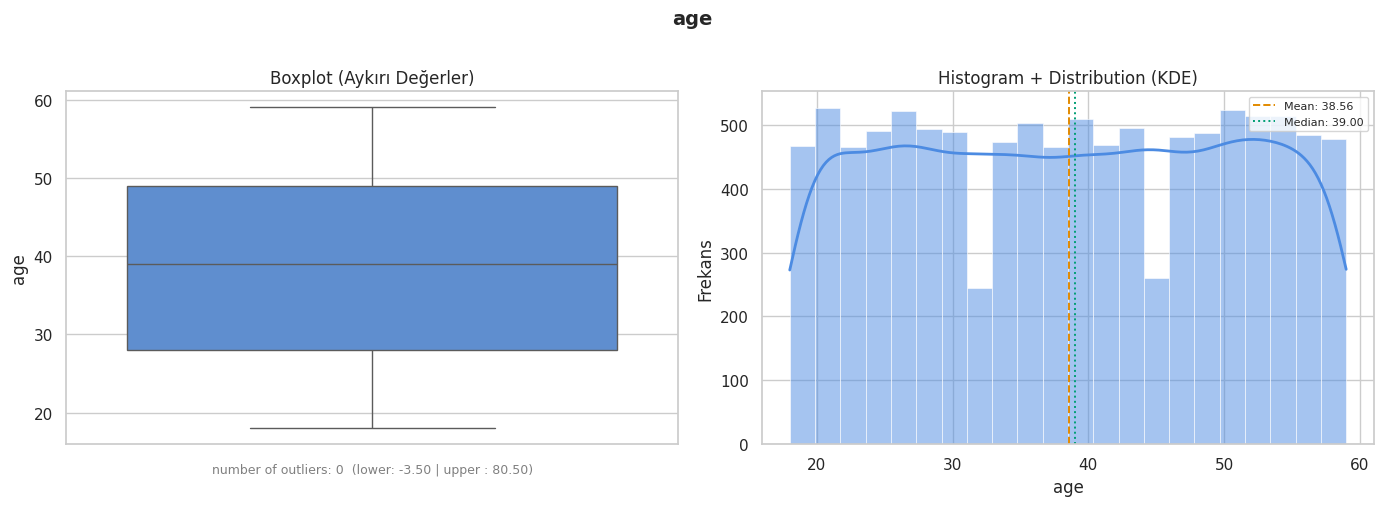

[age] — Outlier indices (0 count): []
----------------------------------------------------------------------


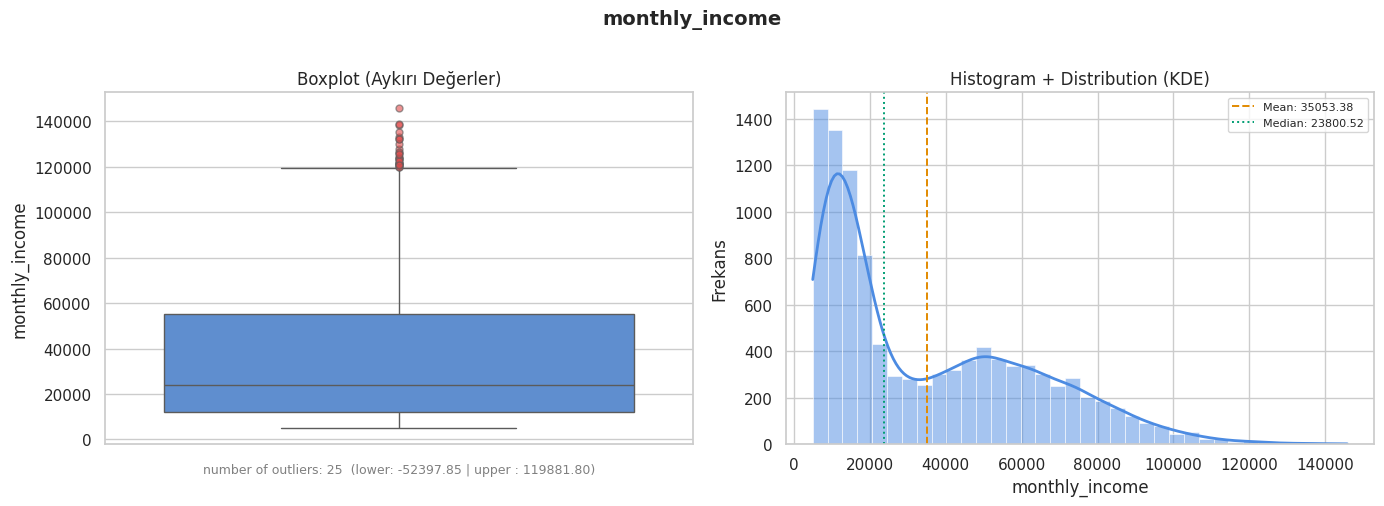

[monthly_income] — Outlier indices (25 count): [583, 861, 1878, 2048, 2580, 3269, 3559, 3738, 3962, 4013, 4513, 4640, 5266, 5605, 5791, 5879, 6162, 6407, 7204, 7442] ...
----------------------------------------------------------------------


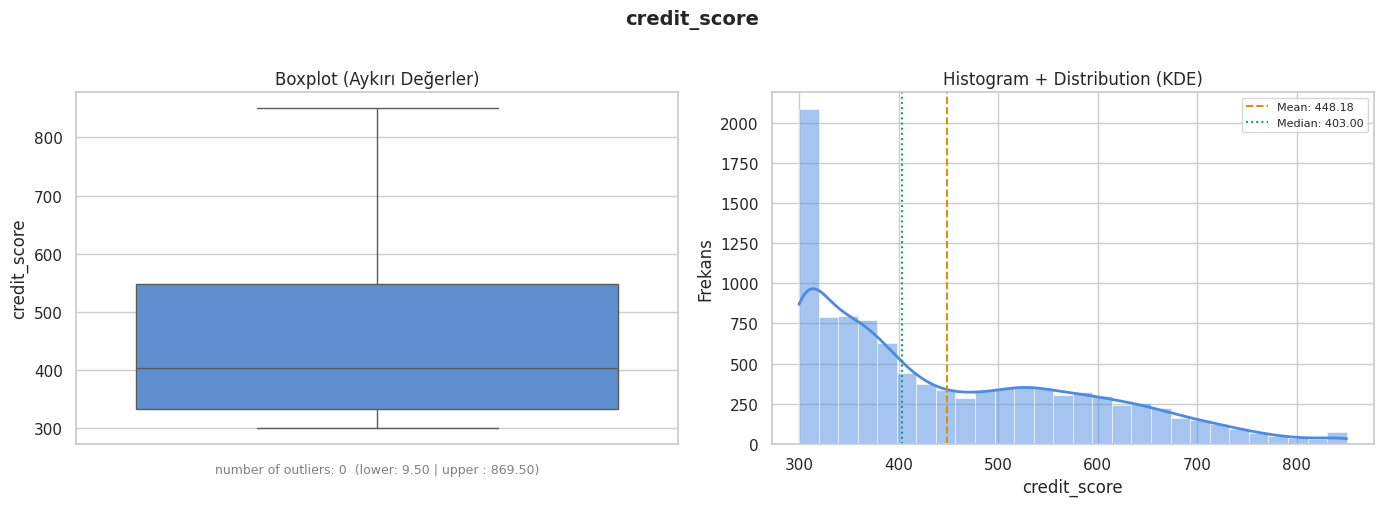

[credit_score] — Outlier indices (0 count): []
----------------------------------------------------------------------


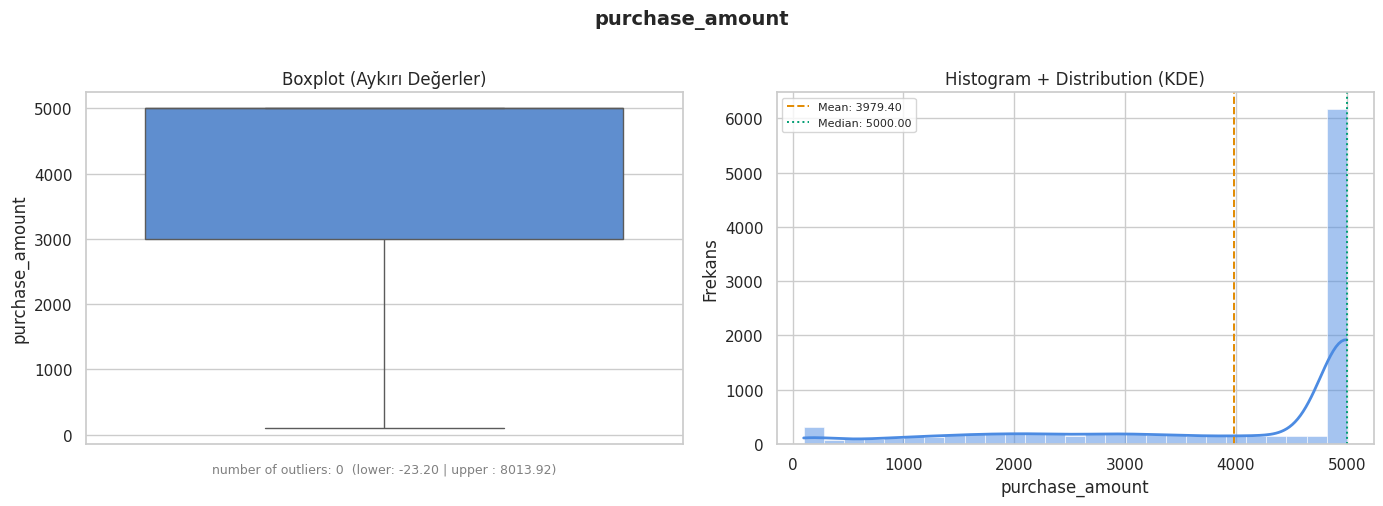

[purchase_amount] — Outlier indices (0 count): []
----------------------------------------------------------------------


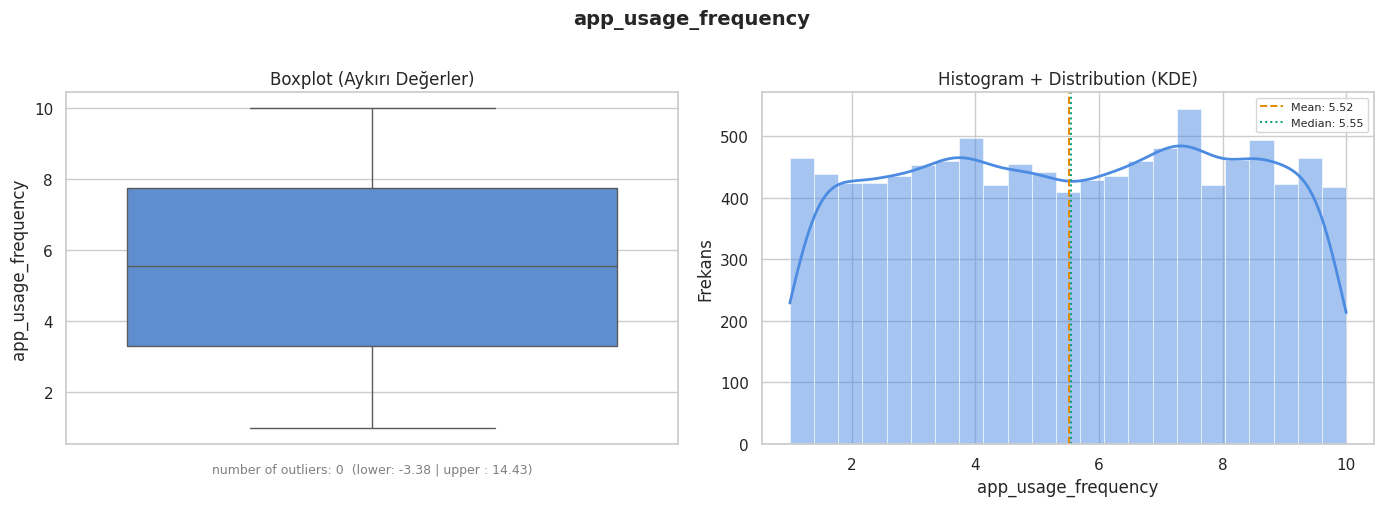

[app_usage_frequency] — Outlier indices (0 count): []
----------------------------------------------------------------------


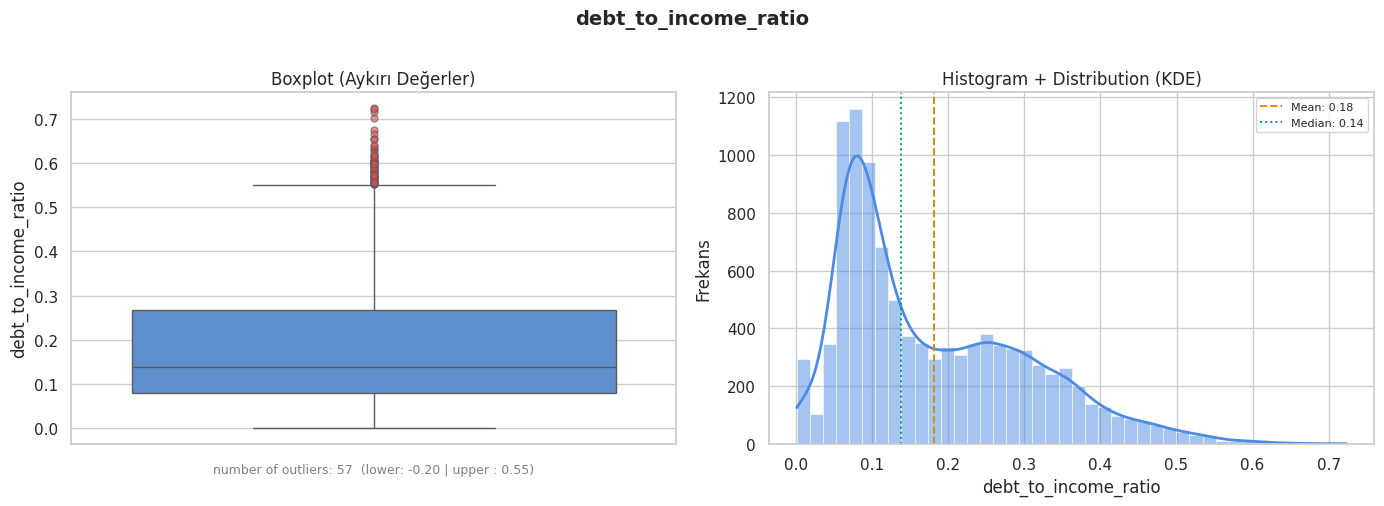

[debt_to_income_ratio] — Outlier indices (57 count): [177, 269, 463, 487, 506, 682, 1011, 1126, 1140, 1241, 1462, 1652, 1796, 1922, 2131, 2209, 2277, 2396, 2827, 2884] ...
----------------------------------------------------------------------


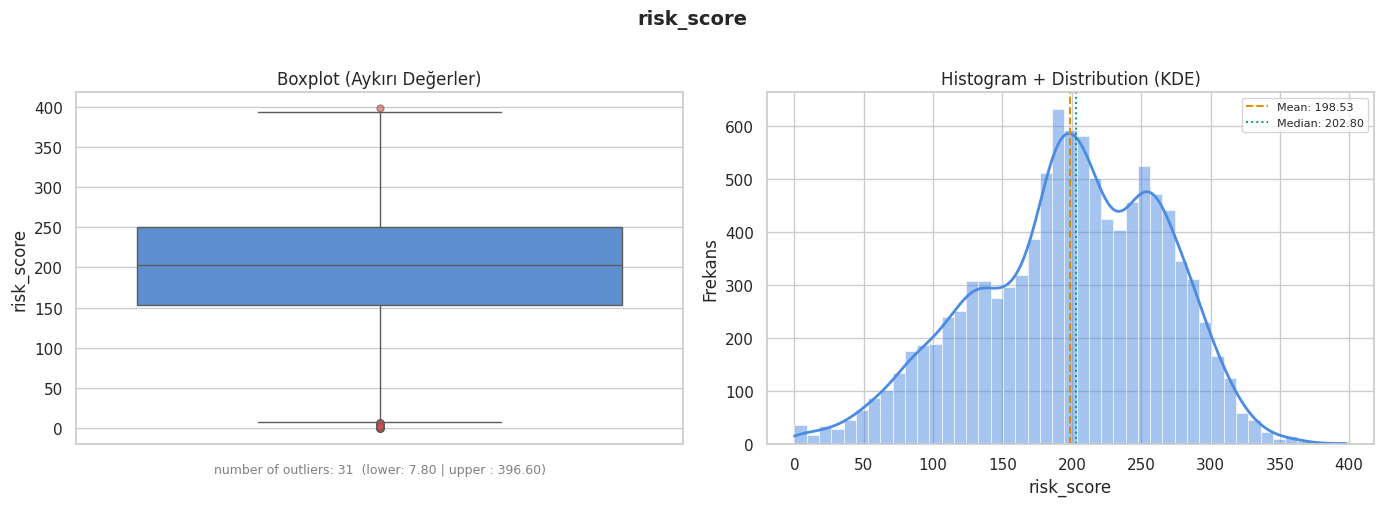

[risk_score] — Outlier indices (31 count): [138, 715, 1131, 1707, 1927, 2301, 2334, 2580, 2824, 2971, 3269, 4013, 4602, 4747, 5605, 6701, 7442, 7786, 8054, 8058] ...
----------------------------------------------------------------------


In [10]:

numeric_cols = [
    'age',
    'monthly_income',
    'credit_score',
    'purchase_amount',
    'app_usage_frequency',
    'debt_to_income_ratio',
    'risk_score'

]
# only linear numreric(without ordinal)

sns.set_theme(style="whitegrid", palette="muted")

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{col}", fontsize=14, fontweight="bold", y=1.01)

    # BOXPLOT
    ax_box = axes[0]
    sns.boxplot(y=data[col], ax=ax_box, color="#4C8BE2",
                flierprops=dict(marker='o', markerfacecolor='#E24C4C',
                                markersize=5, alpha=0.6, linestyle='none'))
    ax_box.set_title("Boxplot (Aykırı Değerler)", fontsize=12)
    ax_box.set_ylabel(col)

    # Calculate outlier indices using the IQR method
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask = (data[col] < lower) | (data[col] > upper)
    outlier_indices = data[col][outlier_mask].index.tolist()
    outlier_vals    = data[col][outlier_mask].values.tolist()

    # An interactive event that displays an index when you click on specific points
    annot = ax_box.annotate("", xy=(0, 0), xytext=(10, 10),
                             textcoords="offset points",
                             bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBCC", ec="gray", lw=0.8),
                             fontsize=8, visible=False)

    # (boxplot x=0)
    outlier_xy = [(0, v) for v in outlier_vals]

    def make_hover(fig_, ax_, annot_, xy_list, idx_list):
        def on_click(event):
            if event.inaxes != ax_:
                return
            for (x, y), idx in zip(xy_list, idx_list):
                disp_x, disp_y = ax_.transData.transform((x, y))
                dist = np.hypot(event.x - disp_x, event.y - disp_y)
                if dist < 8:
                    annot_.set_visible(True)
                    annot_.xy = (x, y)
                    annot_.set_text(f"idx: {idx}\n{y:.4g}")
                    fig_.canvas.draw_idle()
                    return
            annot_.set_visible(False)
            fig_.canvas.draw_idle()
        return on_click

    fig.canvas.mpl_connect(
        'button_press_event',
        make_hover(fig, ax_box, annot, outlier_xy, outlier_indices)
    )

    # the number of outliers as a subtitle
    ax_box.set_xlabel(
        f"number of outliers: {outlier_mask.sum()}  "
        f"(lower: {lower:.2f} | upper : {upper:.2f})",
        fontsize=9, color="gray"
    )

    # ── HİSTOGRAM (with KDE)
    ax_hist = axes[1]
    sns.histplot(data[col].dropna(), ax=ax_hist, kde=True,
                 color="#4C8BE2", edgecolor="white", linewidth=0.4,
                 line_kws={"color": "#E24C4C", "linewidth": 2})
    ax_hist.set_title("Histogram + Distribution (KDE)", fontsize=12)
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel("Frekans")

    # Average and median vertical lines
    mean_val   = data[col].mean()
    median_val = data[col].median()
    ax_hist.axvline(mean_val,   color="#E28A00", linestyle="--", linewidth=1.4, label=f"Mean: {mean_val:.2f}")
    ax_hist.axvline(median_val, color="#009E73", linestyle=":",  linewidth=1.4, label=f"Median: {median_val:.2f}")
    ax_hist.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    print(f"[{col}] — Outlier indices ({len(outlier_indices)} count): {outlier_indices[:20]}"
          + (" ..." if len(outlier_indices) > 20 else ""))
    print("-" * 70)

In [ ]:
data['purchase_amount'].value_counts().head(10)

,count
purchase_amount,
5000.00,6053
100.00,263
1094.29,2
2517.61,2
1121.58,2
2609.55,2
3869.40,2
2721.58,2
2385.61,2


## 5. Bivariate Variable Analysis

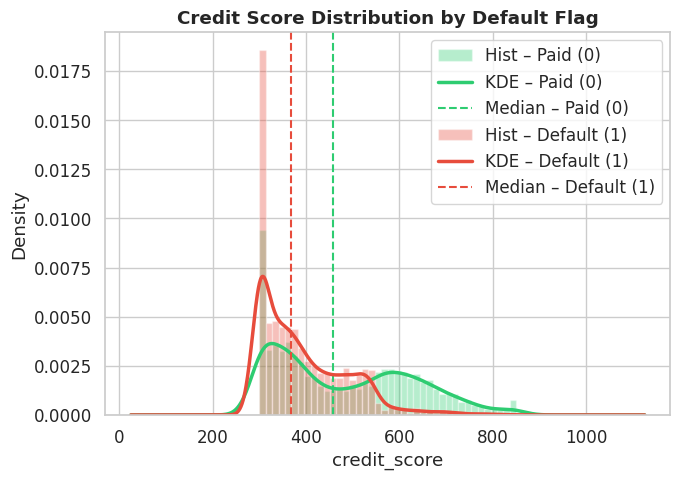

In [28]:
sns.set_theme(style="whitegrid", font_scale=1.1)
GREEN, RED = "#2ecc71", "#e74c3c"
BLUE = "#4C72B0"

# credit_score KDE by default_flag
fig, ax = plt.subplots(figsize=(7, 5))
for flag, color, label in [(0, GREEN, "Paid (0)"), (1, RED, "Default (1)")]:
    s = data.loc[data["default_flag"] == flag, "credit_score"]
    ax.hist(s, bins=40, density=True, alpha=0.35, color=color, label=f"Hist – {label}")
    s.plot.kde(ax=ax, color=color, linewidth=2.5, label=f"KDE – {label}")
    ax.axvline(s.median(), color=color, linestyle="--", linewidth=1.5, label=f"Median – {label}")

ax.set_title("Credit Score Distribution by Default Flag", fontweight="bold")
ax.set_xlabel("credit_score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

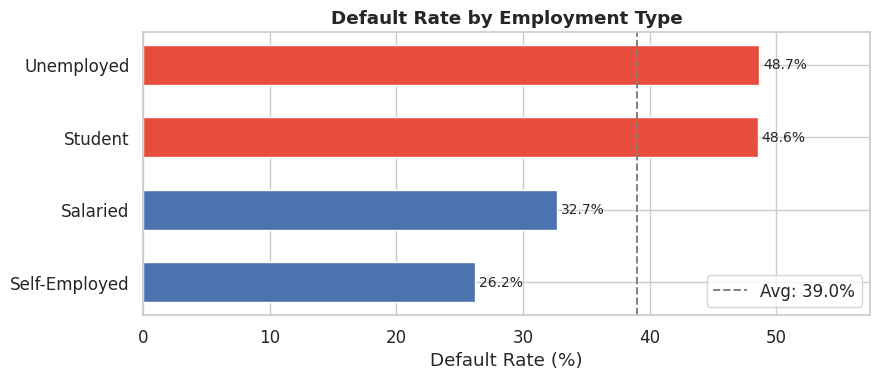

In [29]:
#  Default rate by employment_type
dr = (data.groupby("employment_type")["default_flag"]
        .mean().mul(100).sort_values().reset_index())
dr.columns = ["employment_type", "rate"]
colors = [RED if v >= dr["rate"].median() else BLUE for v in dr["rate"]]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(dr["employment_type"], dr["rate"], color=colors, edgecolor="white", height=0.55)
for bar, val in zip(bars, dr["rate"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.axvline(dr["rate"].mean(), color="gray", linestyle="--", linewidth=1.4,
           label=f"Avg: {dr['rate'].mean():.1f}%")
ax.set_title("Default Rate by Employment Type", fontweight="bold")
ax.set_xlabel("Default Rate (%)")
ax.set_xlim(0, dr["rate"].max() * 1.18)
ax.legend()
plt.tight_layout()
plt.show()

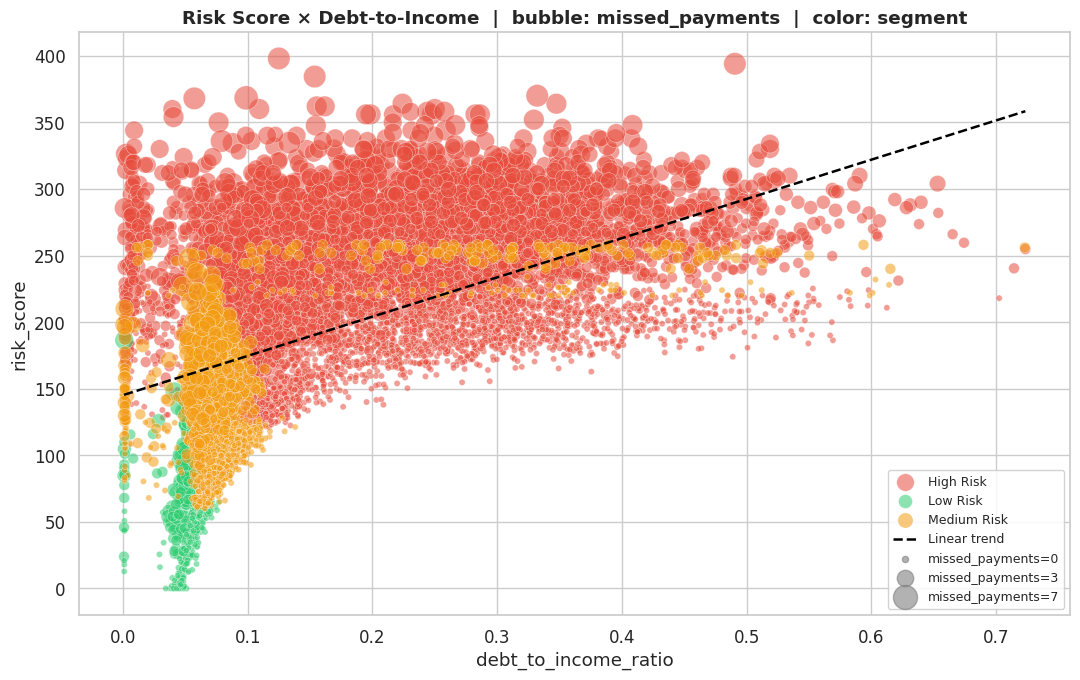

In [33]:
#  risk_score × DTI bubble (missed_payments, customer_segment)
seg_palette = {"Low Risk": "#2ecc71", "Medium Risk": "#f39c12", "High Risk": "#e74c3c"}
size_raw = data["missed_payments"].fillna(0)
size_scaled = 20 + (size_raw - size_raw.min()) / (size_raw.max() - size_raw.min() + 1e-9) * 280

fig, ax = plt.subplots(figsize=(11, 7))
for seg, grp in data.groupby("customer_segment"):
    ax.scatter(grp["debt_to_income_ratio"], grp["risk_score"],
               s=size_scaled[grp.index], alpha=0.55,
               color=seg_palette.get(seg, "gray"),
               edgecolors="white", linewidths=0.4, label=seg)

m, b = np.polyfit(data["debt_to_income_ratio"], data["risk_score"], 1)
x_line = np.linspace(data["debt_to_income_ratio"].min(), data["debt_to_income_ratio"].max(), 200)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8, linestyle="--", label="Linear trend")

for mp_val, lbl in [(0, "0"), (3, "3"), (7, "7")]:
    s = 20 + (mp_val - size_raw.min()) / (size_raw.max() - size_raw.min() + 1e-9) * 280
    ax.scatter([], [], s=s, color="gray", alpha=0.6, label=f"missed_payments={lbl}")

ax.set_title("Risk Score × Debt-to-Income  |  bubble: missed_payments  |  color: segment",
             fontweight="bold")
ax.set_xlabel("debt_to_income_ratio")
ax.set_ylabel("risk_score")
ax.legend(loc="lower right", fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.show()

## 6. Correlation Between Features with Phik


interval columns not set, guessing: ['user_id', 'age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score']


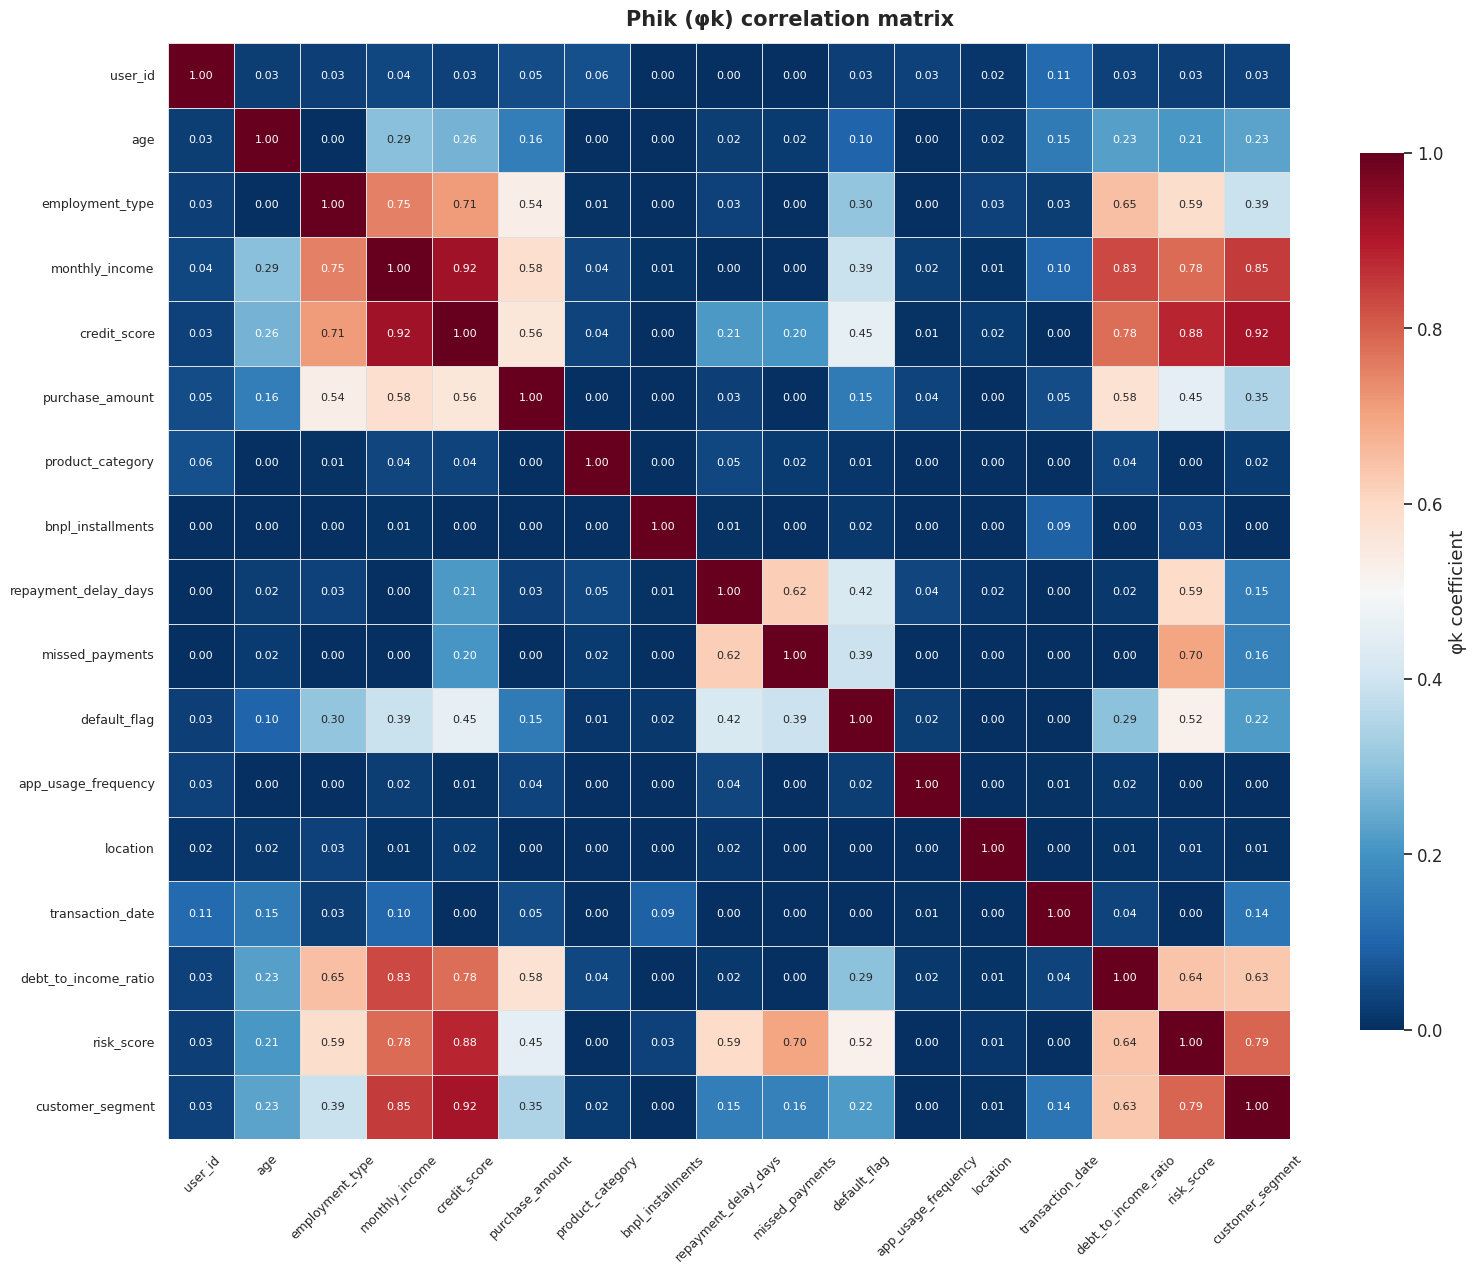


 top 5 correlation pairs :
  monthly_income  ↔  credit_score                   φk: 0.924
  credit_score  ↔  customer_segment               φk: 0.916
  credit_score  ↔  risk_score                     φk: 0.879
  monthly_income  ↔  customer_segment               φk: 0.851
  monthly_income  ↔  debt_to_income_ratio           φk: 0.828


In [14]:
# The phik library is a powerful Python tool designed to calculate the
# correlation (relationship) between variables, particularly for datasets containing both categorical and numerical data.
phik_matrix = data.phik_matrix()

# PLOT
fig, ax = plt.subplots(figsize=(16, 13))
fig.suptitle("Phik (φk) correlation matrix", fontsize=15, fontweight='bold')

sns.heatmap(
    phik_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=0, vmax=1,
    linewidths=0.4,
    linecolor='#e0e0e0',
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "φk coefficient"}
)

ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)

plt.tight_layout()
plt.show()

# top 5 correlation pairs
upper_tri = phik_matrix.where(
    pd.DataFrame(
        __import__('numpy').triu(
            __import__('numpy').ones(phik_matrix.shape), k=1
        ).astype(bool),
        index=phik_matrix.index,
        columns=phik_matrix.columns
    )
)

top5 = (
    upper_tri.stack()
    .sort_values(ascending=False)
    .head(5)
    .round(3)
)

print("\n top 5 correlation pairs :")
print("=" * 50)
for (var1, var2), val in top5.items():
    print(f"  {var1}  ↔  {var2:<30} φk: {val:.3f}")
print("=" * 50)

## 7. Correlation Between Target with Phik

interval columns not set, guessing: ['user_id', 'age', 'monthly_income', 'credit_score', 'purchase_amount', 'bnpl_installments', 'repayment_delay_days', 'missed_payments', 'default_flag', 'app_usage_frequency', 'debt_to_income_ratio', 'risk_score']


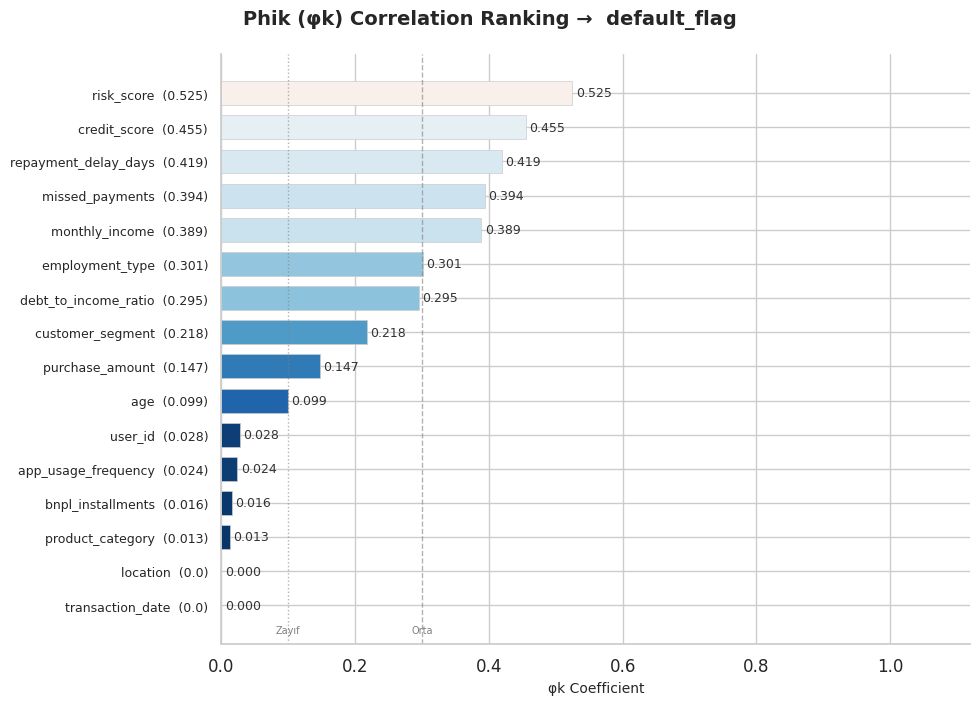

In [34]:
import matplotlib.ticker as ticker

# Calculate the Phik correlation matrix
phik_matrix = data.phik_matrix()

# Retrieve and sort the correlations using 'default_flag'
target_corr = (
    phik_matrix['default_flag']
    .drop('default_flag')
    .sort_values(ascending=False)
    .round(3)
)

labeled_index = [f"{var}  ({val})" for var, val in target_corr.items()]

# PLOT
fig, ax = plt.subplots(figsize=(10, max(6, len(target_corr) * 0.45)))
fig.suptitle("Phik (φk) Correlation Ranking →  default_flag",
             fontsize=14, fontweight='bold')

colors = plt.cm.RdBu_r(target_corr.values)
bars = ax.barh(
    labeled_index[::-1],
    target_corr.values[::-1],
    color=colors[::-1],
    edgecolor='#cccccc',
    linewidth=0.5,
    height=0.7
)

for bar, val in zip(bars, target_corr.values[::-1]):
    ax.text(
        bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va='center', ha='left', fontsize=9, color='#333333'
    )

ax.set_xlim(0, 1.12)
ax.set_xlabel("φk Coefficient", fontsize=10)
ax.axvline(0.1, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.axvline(0.3, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.text(0.1, -0.8, 'Zayıf', fontsize=7, color='gray', ha='center')
ax.text(0.3, -0.8, 'Orta', fontsize=7, color='gray', ha='center')
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.tick_params(axis='y', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder

# Drop columns
df = data.drop(columns=["user_id", "credit_score", "transaction_date", "location"])

# One-Hot Encoding — low cardinality categoricals
# employment_type: Salaried / Self-Employed / Student / Unemployed
# product_category: Electronics / Fashion / Sports / Home / Beauty
df = pd.get_dummies(df, columns=["employment_type", "product_category"], drop_first=True)

#  Label Encoding — ordinal categorical
# customer_segment has a natural order: Low < Medium < High
segment_order = {"Low Risk": 0, "Medium Risk": 1, "High Risk": 2}
df["customer_segment"] = df["customer_segment"].map(segment_order)

# Verify
print(df.shape)
print(df.dtypes)
df.head()

(10345, 18)
age                                int64
monthly_income                   float64
purchase_amount                  float64
bnpl_installments                  int64
repayment_delay_days               int64
missed_payments                    int64
default_flag                       int64
app_usage_frequency              float64
debt_to_income_ratio             float64
risk_score                       float64
customer_segment                   int64
employment_type_Self-Employed       bool
employment_type_Student             bool
employment_type_Unemployed          bool
product_category_Electronics        bool
product_category_Fashion            bool
product_category_Home               bool
product_category_Sports             bool
dtype: object


,age,monthly_income,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score,customer_segment,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,product_category_Electronics,product_category_Fashion,product_category_Home,product_category_Sports
0,56,68529.50,5000.00,12,13,1,0,8.49,0.072961,165.2,1,False,False,False,True,False,False,False
1,19,7247.85,1073.23,12,13,1,0,3.09,0.148076,266.0,2,False,True,False,False,True,False,False
2,20,41582.26,5000.00,3,19,2,0,3.33,0.120244,229.6,2,True,False,False,True,False,False,False
3,21,14423.46,4076.83,6,18,5,1,5.86,0.282653,356.0,2,False,False,False,False,False,False,True
4,43,42845.50,5000.00,9,0,0,0,7.36,0.116698,135.2,2,False,False,False,True,False,False,False


              precision    recall  f1-score   support

        Paid       0.78      0.65      0.71      1261
     Default       0.57      0.71      0.63       808

    accuracy                           0.67      2069
   macro avg       0.67      0.68      0.67      2069
weighted avg       0.70      0.67      0.68      2069

AUC-ROC  : 0.7824
PR-AUC   : 0.7128
5-Fold CV AUC-ROC: 0.7697 ± 0.0041


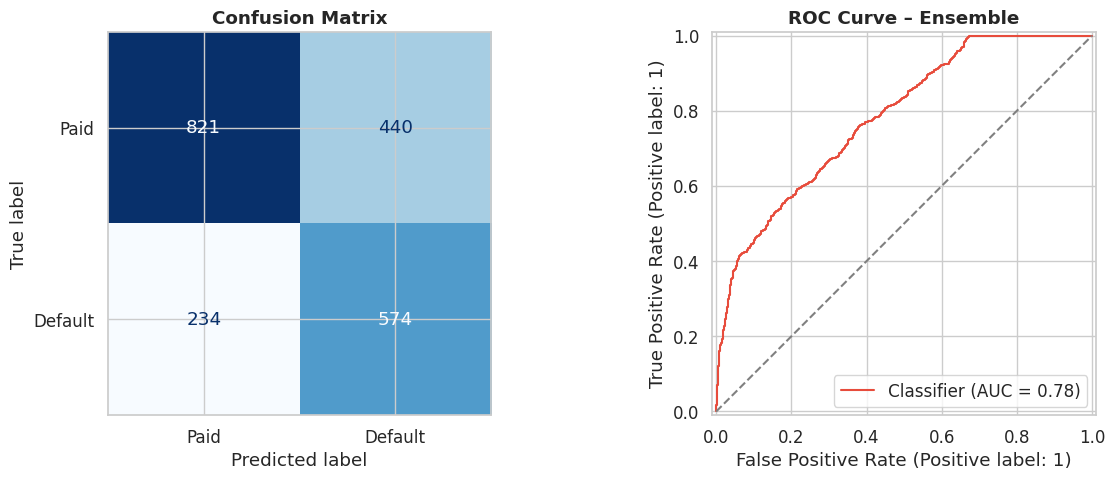

In [30]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, ConfusionMatrixDisplay,
                             RocCurveDisplay, confusion_matrix)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


#  Train / Test Split
X = df.drop(columns=["default_flag"])
y = df["default_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# class imbalance weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos   # scale_pos_weight for XGB / LGB

# Base Models
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    scale_pos_weight=spw, eval_metric="aucpr",
    random_state=42, use_label_encoder=False
)

lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    scale_pos_weight=spw, random_state=42, verbose=-1
)

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ))
])

# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[("xgb", xgb), ("lgbm", lgbm), ("lr", lr)],
    voting="soft",
    weights=[2, 2, 1]   # XGB & LGBM'e daha fazla ağırlık
)

# Fit
ensemble.fit(X_train, y_train)

# Predictions
y_pred      = ensemble.predict(X_test)
y_prob      = ensemble.predict_proba(X_test)[:, 1]

# Metrics
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Paid", "Default"]))
print(f"AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.4f}")
print("=" * 50)

#  Cross-Validation (AUC-ROC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ensemble, X, y, cv=cv, scoring="roc_auc")
print(f"5-Fold CV AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Paid", "Default"],
    colorbar=False, ax=axes[0], cmap="Blues"
)
axes[0].set_title("Confusion Matrix", fontweight="bold")

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color="#e74c3c")
axes[1].plot([0,1],[0,1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve – Ensemble", fontweight="bold")

plt.tight_layout()
plt.show()

# 10. Result

Avg purchase amount in test set: $4004.47
Baseline profit (no model): $-3,172,562

Optimal Threshold : 0.0789
Max Model Profit  : $3,205,553
Profit vs Baseline: $+6,378,115

At threshold 0.08 → TP:807  FP:851  FN:1  TN:410


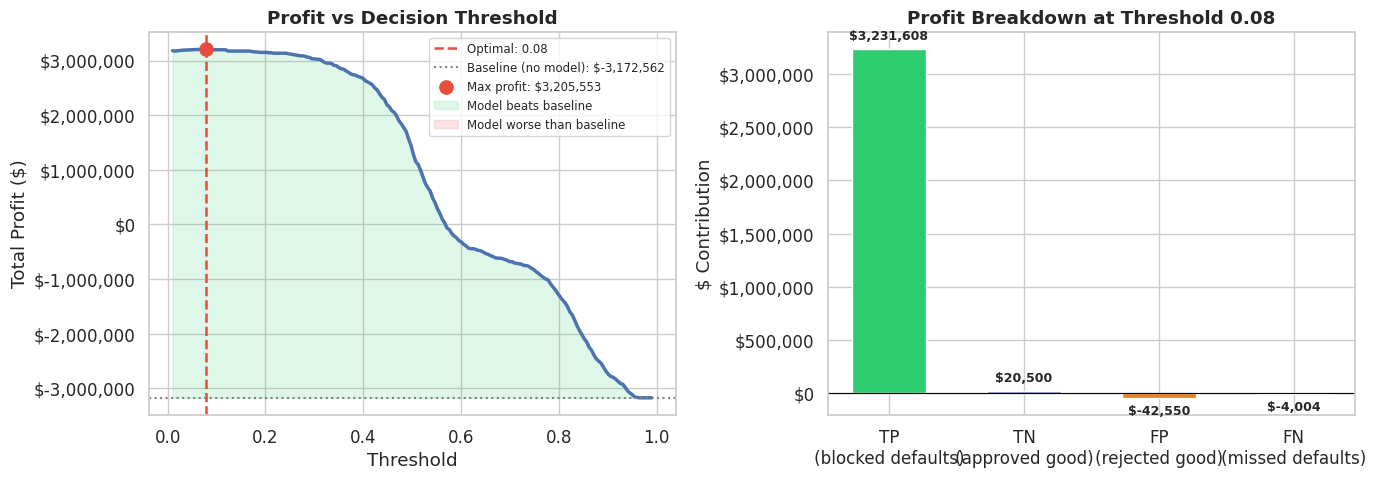

In [31]:
# Cost / Benefit assumptions
# TP  → default correctly blocked  : full purchase_amount saved (avg)
# FP  → good customer rejected     : -50$ lost commission
# FN  → default missed             : -purchase_amount lost (avg)
# TN  → good customer approved     : +50$ commission earned

AVG_PURCHASE   = X_test["purchase_amount"].mean()   # dynamic from test set
COMMISSION     = 50                                  # $ per approved good customer

print(f"Avg purchase amount in test set: ${AVG_PURCHASE:.2f}")

#  Baseline: no model (approve everyone)
n_paid    = (y_test == 0).sum()
n_default = (y_test == 1).sum()

baseline_profit = (n_paid * COMMISSION) - (n_default * AVG_PURCHASE)
print(f"Baseline profit (no model): ${baseline_profit:,.0f}")

# Sweep thresholds
thresholds = np.linspace(0.01, 0.99, 200)
profits    = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    profit = (tp * AVG_PURCHASE) + (tn * COMMISSION) \
           - (fp * COMMISSION)   - (fn * AVG_PURCHASE)
    profits.append(profit)

profits = np.array(profits)
best_idx    = np.argmax(profits)
best_t      = thresholds[best_idx]
best_profit = profits[best_idx]

print(f"\nOptimal Threshold : {best_t:.4f}")
print(f"Max Model Profit  : ${best_profit:,.0f}")
print(f"Profit vs Baseline: ${best_profit - baseline_profit:+,.0f}")

#  Confusion matrix at best threshold
y_pred_best = (y_prob >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
print(f"\nAt threshold {best_t:.2f} → TP:{tp}  FP:{fp}  FN:{fn}  TN:{tn}")

#  Plot 1: Profit vs Threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresholds, profits, color="#4C72B0", linewidth=2.5)
ax.axvline(best_t, color="#e74c3c", linestyle="--", linewidth=1.8,
           label=f"Optimal: {best_t:.2f}")
ax.axhline(baseline_profit, color="gray", linestyle=":", linewidth=1.5,
           label=f"Baseline (no model): ${baseline_profit:,.0f}")
ax.scatter([best_t], [best_profit], color="#e74c3c", s=90, zorder=5,
           label=f"Max profit: ${best_profit:,.0f}")
ax.fill_between(thresholds, baseline_profit, profits,
                where=(profits > baseline_profit),
                alpha=0.15, color="#2ecc71", label="Model beats baseline")
ax.fill_between(thresholds, baseline_profit, profits,
                where=(profits < baseline_profit),
                alpha=0.15, color="#e74c3c", label="Model worse than baseline")
import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Profit vs Decision Threshold", fontweight="bold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Total Profit ($)")
ax.legend(fontsize=8.5)

# Plot 2: Profit breakdown bar (TP / TN / FP / FN contribution)
ax2 = axes[1]
components = {
    "TP\n(blocked defaults)": tp * AVG_PURCHASE,
    "TN\n(approved good)":    tn * COMMISSION,
    "FP\n(rejected good)":   -fp * COMMISSION,
    "FN\n(missed defaults)": -fn * AVG_PURCHASE,
}
colors = ["#2ecc71", "#4C72B0", "#e67e22", "#e74c3c"]
bars = ax2.bar(components.keys(), components.values(), color=colors, edgecolor="white", width=0.55)

for bar, val in zip(bars, components.values()):
    va    = "bottom" if val >= 0 else "top"
    offset = max(abs(v) for v in components.values()) * 0.02
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (offset if val >= 0 else -offset),
             f"${val:,.0f}", ha="center", va=va, fontsize=9, fontweight="bold")

ax2.axhline(0, color="black", linewidth=0.8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.set_title(f"Profit Breakdown at Threshold {best_t:.2f}", fontweight="bold")
ax2.set_ylabel("$ Contribution")

plt.tight_layout()
plt.show()